In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 20.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 18.2 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   -------------- ------------------------- 4.5/12.5 MB 21.7 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.5 MB 20.0 MB/s eta 0:00:01
   -------------------------------------- - 12.1/12.5 MB 19.4 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 16.4 MB/s  0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------- ----------------------- 4.2/10.2 MB 19.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.9/10.2 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 18.0 MB/s  0:00:00
   ----------------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [10]:
df = pd.read_csv(r"J:/Customer-Segmentation-Project/data/store_customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [13]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [28]:
df = df.dropna()

In [29]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

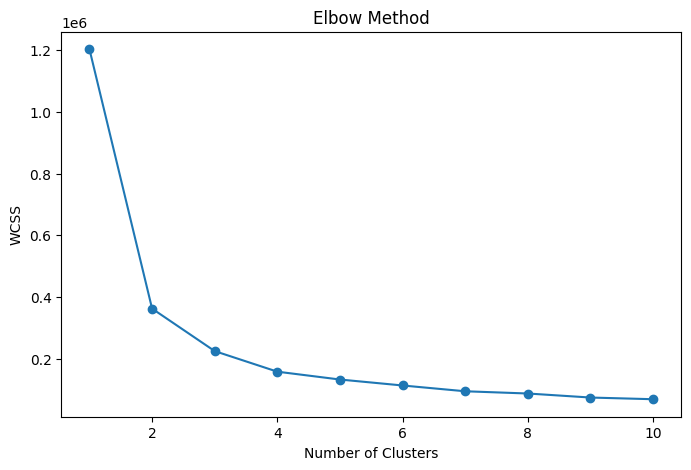

In [30]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

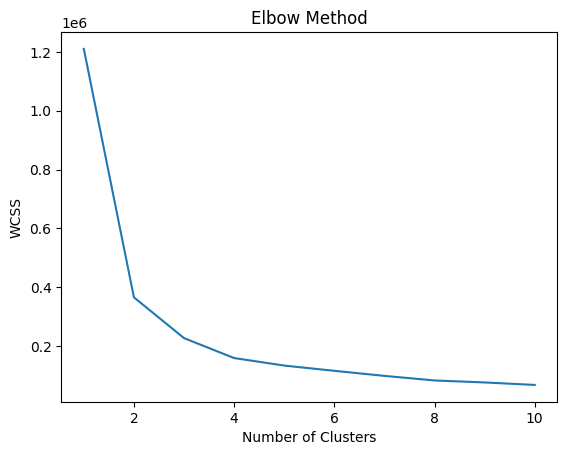

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [31]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

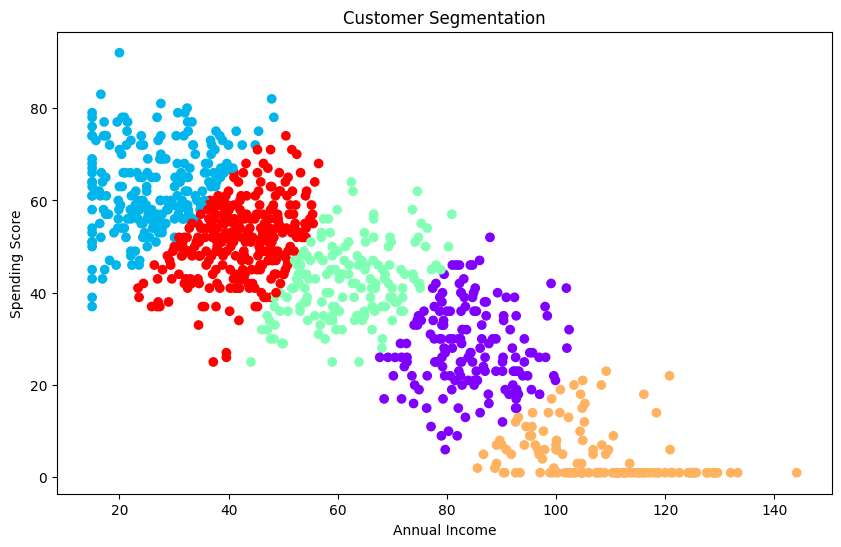

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='rainbow'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [34]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

          CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                    
0        1497.621951  46.359756           84.168293               28.231707
1        1463.743363  26.774336           26.509735               62.752212
2        1427.818750  38.962500           61.746250               42.218750
3        1819.554688  65.968750          108.168750                4.851562
4        1432.661184  32.648026           42.023355               51.476974


In [35]:
df['Cluster'].value_counts()

Cluster
4    304
1    226
0    164
2    160
3    128
Name: count, dtype: int64

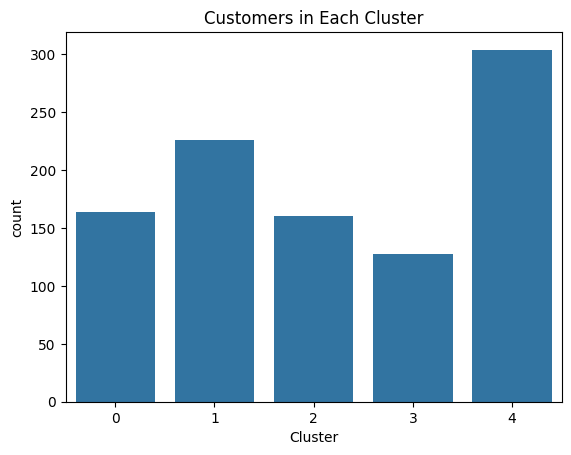

In [36]:
import seaborn as sns

sns.countplot(x='Cluster', data=df)

plt.title("Customers in Each Cluster")

plt.show()